# Phase 04.00 — Question-type and paired-error analysis

This notebook discovers completed full-run prediction files from Phases 01–03, verifies every file against the frozen validation membership, computes question-type slices, and exports paired error transitions and representative failures.


In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path("/workspace/RoadBuddy")
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.environ.setdefault("CC", "/usr/bin/gcc")
os.environ.setdefault("CXX", "/usr/bin/g++")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from roadbuddy_common import *

os.chdir(PROJECT_ROOT)
seed_everything(SEED)
ensure_dirs()
print("Project root:", PROJECT_ROOT)
print("Model revision:", MODEL_REVISION)


Project root: /workspace/RoadBuddy
Model revision: b98f263eab246eb5269ade64edbdca8a887dc44d


## 1. Discover completed predictions

Only `full` runs are included. Missing phases are reported explicitly; debug predictions never enter the analysis.


In [2]:
import matplotlib.pyplot as plt

OUTPUT_ROOT = PROJECT_ROOT / "outputs/phase04/question_type_analysis"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
frozen_ids = set(json.loads((PATHS.phase1_split / "validation_sample_ids.json").read_text(encoding="utf-8")))
phase1_status = json.loads((PATHS.phase1_output / "PHASE01_STATUS.json").read_text(encoding="utf-8"))
run_scope = phase1_status.get("run_name", "full")

prediction_sources = {
    "phase01_zero_shot_F1": PATHS.zero_shot / run_scope / "predictions.csv",
    "phase01_lora_r16_F1": PATHS.lora / run_scope / "evaluation/validation_predictions.csv",
}
for path in sorted((PROJECT_ROOT / "outputs/phase02/multiframe_f1_f3_f8").glob(f"*/F*/{run_scope}/predictions.csv")):
    prediction_sources[f"phase02_{path.parts[-4]}_{path.parts[-3]}"] = path
for path in sorted((PROJECT_ROOT / "outputs/phase03/lora_rank_ablation").glob(f"r*/{run_scope}/evaluation/validation_predictions.csv")):
    prediction_sources[f"phase03_{path.parts[-4]}_F1"] = path

missing = {name: str(path) for name, path in prediction_sources.items() if not path.is_file()}
available = {name: path for name, path in prediction_sources.items() if path.is_file()}
print("Run scope:", run_scope)
print("Available experiments:", sorted(available))
print("Missing expected files:", missing)
assert "phase01_zero_shot_F1" in available, f"Phase 01 zero-shot predictions are required for scope {run_scope}"

Run scope: debug20
Available experiments: ['phase01_lora_r16_F1', 'phase01_zero_shot_F1', 'phase02_lora_r16_F1', 'phase02_lora_r16_F3', 'phase02_lora_r16_F8', 'phase02_zero_shot_F1', 'phase02_zero_shot_F3', 'phase02_zero_shot_F8', 'phase03_r8_F1']
Missing expected files: {}


## 2. Membership validation and unified table


In [3]:
baseline_ids = set(pd.read_csv(available["phase01_zero_shot_F1"]).sample_id.astype(str))
assert baseline_ids, "Baseline prediction file is empty"
assert baseline_ids <= frozen_ids, "Baseline IDs are not a subset of frozen validation IDs"

frames = []
for experiment, path in available.items():
    frame = pd.read_csv(path)
    assert frame.sample_id.is_unique, f"Duplicate sample IDs in {experiment}"
    assert set(frame.sample_id.astype(str)) == baseline_ids, f"Prediction membership mismatch in {experiment}"
    frame["experiment"] = experiment
    frames.append(frame)
all_predictions = pd.concat(frames, ignore_index=True)
all_predictions.to_csv(OUTPUT_ROOT / f"all_predictions_{run_scope}.csv", index=False)
print("Experiments:", all_predictions.experiment.nunique(), "Rows:", len(all_predictions), "Evaluation IDs:", len(baseline_ids))

Experiments: 9 Rows: 180 Evaluation IDs: 20


## 3. Metrics by question type

Slices with fewer than 20 examples are flagged as exploratory rather than treated as stable conclusions.


In [4]:
slice_rows = []
for (experiment, qtype), group in all_predictions.groupby(["experiment", "question_type"], dropna=False):
    parsed = group.prediction.fillna("INVALID")
    accuracy = float(accuracy_score(group.answer, parsed))
    n = len(group)
    radius = 1.96 * math.sqrt(max(accuracy * (1 - accuracy), 1e-12) / n)
    slice_rows.append({
        "experiment": experiment, "question_type": qtype, "rows": n,
        "accuracy": accuracy,
        "macro_f1": float(f1_score(group.answer, parsed, labels=list(CHOICES), average="macro", zero_division=0)),
        "parse_rate": float(group.prediction.notna().mean()),
        "accuracy_ci95_low": max(0.0, accuracy - radius), "accuracy_ci95_high": min(1.0, accuracy + radius),
        "interpretation": "stable_candidate" if n >= 20 else "exploratory_small_slice",
    })
slices = pd.DataFrame(slice_rows).sort_values(["question_type", "accuracy"], ascending=[True, False])
slices.to_csv(OUTPUT_ROOT / "metrics_by_question_type.csv", index=False)
display(slices)


,experiment,question_type,rows,accuracy,macro_f1,parse_rate,accuracy_ci95_low,accuracy_ci95_high,interpretation
5,phase02_zero_shot_F1,unknown,20,0.70,0.663690,1.0,0.499160,0.900840,stable_candidate
1,phase01_zero_shot_F1,unknown,20,0.65,0.598485,1.0,0.440959,0.859041,stable_candidate
6,phase02_zero_shot_F3,unknown,20,0.65,0.596667,1.0,0.440959,0.859041,stable_candidate
8,phase03_r8_F1,unknown,20,0.65,0.598485,1.0,0.440959,0.859041,stable_candidate
0,phase01_lora_r16_F1,unknown,20,0.60,0.569444,1.0,0.385293,0.814707,stable_candidate
2,phase02_lora_r16_F1,unknown,20,0.60,0.616228,1.0,0.385293,0.814707,stable_candidate
3,phase02_lora_r16_F3,unknown,20,0.60,0.603535,1.0,0.385293,0.814707,stable_candidate
4,phase02_lora_r16_F8,unknown,20,0.60,0.603535,1.0,0.385293,0.814707,stable_candidate
7,phase02_zero_shot_F8,unknown,20,0.60,0.603535,1.0,0.385293,0.814707,stable_candidate


## 4. Paired transitions against zero-shot F1


In [5]:
baseline = all_predictions[all_predictions.experiment == "phase01_zero_shot_F1"][["sample_id", "answer", "question_type", "correct"]].rename(columns={"correct": "baseline_correct"})
transitions = []
for experiment, candidate in all_predictions.groupby("experiment"):
    if experiment == "phase01_zero_shot_F1":
        continue
    paired = baseline.merge(candidate[["sample_id", "correct", "prediction", "raw_response"]], on="sample_id", validate="one_to_one")
    paired["experiment"] = experiment
    paired["transition"] = np.select(
        [~paired.baseline_correct & paired.correct, paired.baseline_correct & ~paired.correct],
        ["wrong_to_right", "right_to_wrong"], default="unchanged",
    )
    transitions.append(paired)
paired_transitions = pd.concat(transitions, ignore_index=True) if transitions else pd.DataFrame()
paired_transitions.to_csv(OUTPUT_ROOT / "paired_transitions_vs_zero_shot_f1.csv", index=False)
transition_summary = paired_transitions.groupby(["experiment", "transition"]).size().rename("rows").reset_index() if len(paired_transitions) else pd.DataFrame()
transition_summary.to_csv(OUTPUT_ROOT / "paired_transition_summary.csv", index=False)
display(transition_summary)


,experiment,transition,rows
0,phase01_lora_r16_F1,right_to_wrong,1
1,phase01_lora_r16_F1,unchanged,19
2,phase02_lora_r16_F1,right_to_wrong,2
3,phase02_lora_r16_F1,unchanged,17
4,phase02_lora_r16_F1,wrong_to_right,1
5,phase02_lora_r16_F3,right_to_wrong,1
6,phase02_lora_r16_F3,unchanged,19
7,phase02_lora_r16_F8,right_to_wrong,1
8,phase02_lora_r16_F8,unchanged,19
9,phase02_zero_shot_F1,unchanged,19


## 5. Chart, representative errors, and phase status


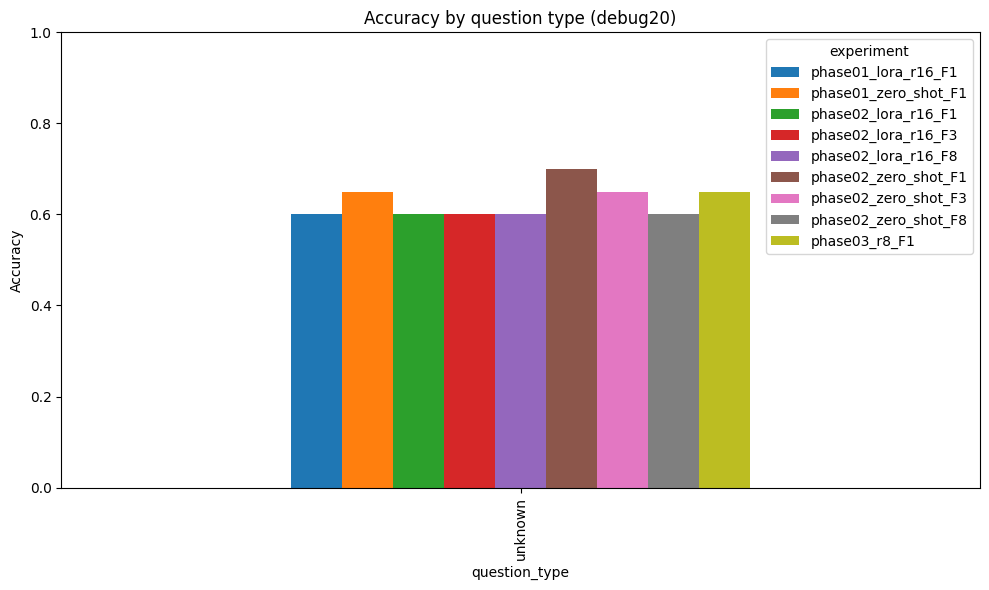

Phase 04 debug20: DEBUG_COMPLETE


In [6]:
pivot = slices.pivot(index="question_type", columns="experiment", values="accuracy")
ax = pivot.plot(kind="bar", figsize=(max(10, len(pivot) * 1.2), 6), ylim=(0, 1), title=f"Accuracy by question type ({run_scope})")
ax.set_ylabel("Accuracy")
ax.figure.tight_layout()
ax.figure.savefig(OUTPUT_ROOT / f"accuracy_by_question_type_{run_scope}.png", dpi=160)
plt.show()

errors = all_predictions[~all_predictions.correct.astype(bool)].copy()
representative = errors.sort_values(["experiment", "question_type", "sample_id"]).groupby(["experiment", "question_type"], dropna=False).head(5)
representative.to_csv(OUTPUT_ROOT / f"representative_errors_{run_scope}.csv", index=False)

phase_status = "complete" if run_scope == "full" else "debug_complete"
save_json(OUTPUT_ROOT / "PHASE04_STATUS.json", {
    "phase": "04", "status": phase_status, "run_name": run_scope,
    "experiments": int(all_predictions.experiment.nunique()),
    "question_types": int(all_predictions.question_type.nunique()), "validation_rows": len(baseline_ids),
    "small_slice_threshold": 20, "model_revision": MODEL_REVISION, "seed": SEED,
})
print(f"Phase 04 {run_scope}: {phase_status.upper()}")